# ECF 4: Pipeline NLP complet — TF-IDF · TensorFlow · FastAPI

## Partie 1 — Chargement et exploration

### 1.1 Chargement et constitution du corpus de titres

Écrivez une fonction `load_titles(filepath: str) -> pd.DataFrame` qui :

- Charge le fichier CSV
- Sélectionne et renomme les colonnes utiles : `title` → `text`, `label` → `label`
- Convertit les labels textuels en entiers : `REAL` → 1, `FAKE` → 0
- Supprime les lignes dont le titre est vide ou nul
- Affiche un résumé : nombre de titres par classe, proportion, longueur moyenne

Sauvegardez le DataFrame résultant dans `data/titles_clean.csv`.

In [1]:
import pandas as pd 
from pathlib import Path

def load_titles(filepath: str) -> pd.DataFrame:
    """
        Charge le dataset de fake news, conserve uniquement les titres,
        convertit les labels en entiers et affiche un résumé du corpus.

        Params
        ----------
        filepath : str
            Path to the CSV source file path.

        Return
        ------
        pd.DataFrame
            Clean DataFrame with 2 columns :
            - text : title of the article
            - label : 1 -> REAL, 0 -> FAKE
    """
    # Chargement
    df = pd.read_csv(filepath)

    # Vérification des colonnes attendues
    required_cols = {"title", "label"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"Colonnes manquantes dans le fichier : {missing_cols}")

    # Sélection et renommage
    df = df[["title", "label"]].rename(columns={"title": "text"})

    # Suppression des titres nuls
    df = df.dropna(subset=["text"])

    # Nettoyage des espaces
    df["text"] = df["text"].astype(str).str.strip()

    # Suppression des titres vides
    df = df[df["text"] != ""]

    # Conversion des labels
    label_map = {"REAL": 1, "FAKE": 0}
    df["label"] = df["label"].map(label_map)

    # Suppression des lignes avec label inconnu
    df = df.dropna(subset=["label"])

    # Conversion finale en int
    df["label"] = df["label"].astype(int)

    # Calculs de résumé
    class_counts = df["label"].value_counts().sort_index()
    class_names = {0: "FAKE", 1: "REAL"}
    proportions = df["label"].value_counts(normalize=True).sort_index() * 100
    avg_length = df["text"].str.len().mean()

    print("\n=== Résumé ===")
    print(f"Nombre total de titres : {len(df)}")
    print(f"Longueur moyenne des titres : {avg_length:.2f} caractères\n")

    for label_value in class_counts.index:
        print(
            f"{class_names[label_value]} ({label_value}) : "
            f"{class_counts[label_value]} titres "
            f"({proportions[label_value]:.2f} %)"
        )

    return df

df_titles = load_titles("../data/fake_or_real_news.csv")

Path("data").mkdir(parents=True, exist_ok=True)
df_titles.to_csv("../data/titles_clean.csv", index=False, encoding="utf-8")

df_titles.head()


=== Résumé ===
Nombre total de titres : 6335
Longueur moyenne des titres : 65.28 caractères

FAKE (0) : 3164 titres (49.94 %)
REAL (1) : 3171 titres (50.06 %)


,text,label
0,You Can Smell Hillary’s Fear,0
1,Watch The Exact Moment Paul Ryan Committed Pol...,0
2,Kerry to go to Paris in gesture of sympathy,1
3,Bernie supporters on Twitter erupt in anger ag...,0
4,The Battle of New York: Why This Primary Matters,1


In [2]:
# Vérification
print(df_titles.info())
print(df_titles.sample(5))
print(df_titles["label"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    6335 non-null   str  
 1   label   6335 non-null   int64
dtypes: int64(1), str(1)
memory usage: 99.1 KB
None
                                                   text  label
1374           8 Things Congress Actually Did This Year      1
2688          5 things to watch in tonight’s GOP debate      1
3637  Mitch McConnell Pledges To Avoid Debt Ceiling ...      1
3509  Trump, Clinton cautiously optimistic ahead of ...      1
3818             New Senate is just like the old Senate      1
label
1    3171
0    3164
Name: count, dtype: int64


### 1.2 Analyse exploratoire

Réalisez les analyses suivantes et commentez chaque résultat dans une cellule Markdown :

- Distribution des classes : le corpus est-il équilibré ? Si non, quelle stratégie envisagez-vous ?

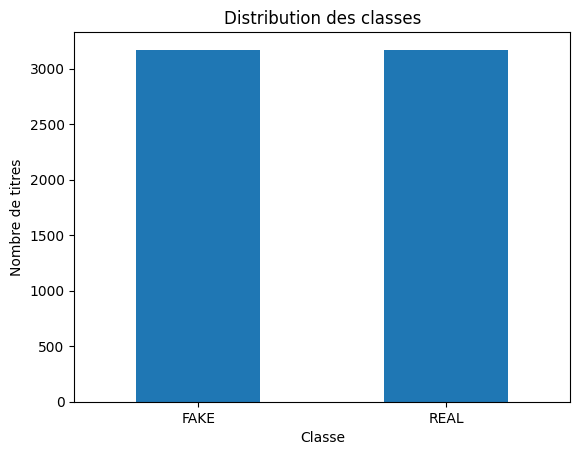

label
1    3171
0    3164
Name: count, dtype: int64
label
1    0.500552
0    0.499448
Name: count, dtype: float64


In [3]:
import matplotlib.pyplot as plt

class_counts = df_titles["label"].value_counts()

plt.figure()
class_counts.plot(kind="bar")
plt.xticks([0, 1], ["FAKE", "REAL"], rotation=0)
plt.title("Distribution des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre de titres")
plt.show()

print(class_counts)
print(class_counts / len(df_titles))

Le dataset est globalement équilibré

- Distribution de la longueur des titres en tokens : histogramme par classe, valeurs min / max / médiane

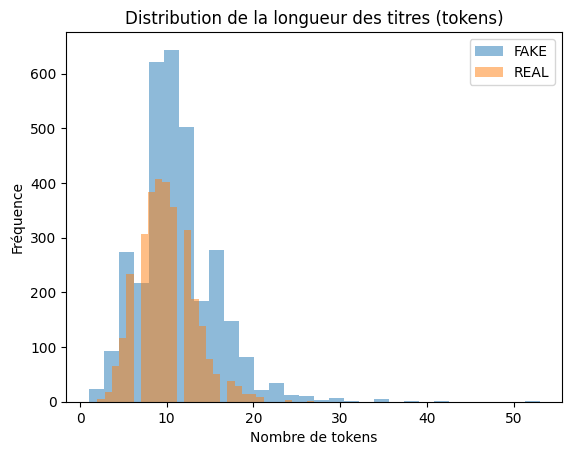

       min  max  median
label                  
0        1   53    11.0
1        2   27    10.0


In [4]:
# Tokenisation simple
df_titles["token_count"] = df_titles["text"].apply(lambda x: len(x.split()))

# Histogramme
plt.figure()
for label, name in zip([0, 1], ["FAKE", "REAL"]):
    subset = df_titles[df_titles["label"] == label]
    plt.hist(subset["token_count"], bins=30, alpha=0.5, label=name)

plt.title("Distribution de la longueur des titres (tokens)")
plt.xlabel("Nombre de tokens")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

# Statistiques
stats = df_titles.groupby("label")["token_count"].agg(["min", "max", "median"])
print(stats)

L’analyse de la longueur des titres en nombre de tokens montre que :

Les titres FAKE (0) varient entre 1 et 53 tokens, avec une médiane de 11
Les titres REAL (1) varient entre 2 et 27 tokens, avec une médiane de 10

On observe que les distributions sont globalement similaires en termes de médiane.

Cependant, les titres FAKE présentent une variabilité beaucoup plus élevée, avec des titres pouvant être très longs.

Cela peut s’expliquer par le fait que les contenus trompeurs utilisent parfois des titres plus longs pour :

- attirer l’attention (clickbait)
- ajouter du sensationnel ou du contexte artificiel

À l’inverse, les titres REAL sont plus homogènes et concis, ce qui correspond à un style journalistique plus standardisé.

Cette différence de dispersion peut être exploitée indirectement par le modèle, mais elle ne constitue pas à elle seule un critère suffisant de classification.

- Top 20 des tokens les plus fréquents dans chaque classe — affichez deux diagrammes en barres côte à côte

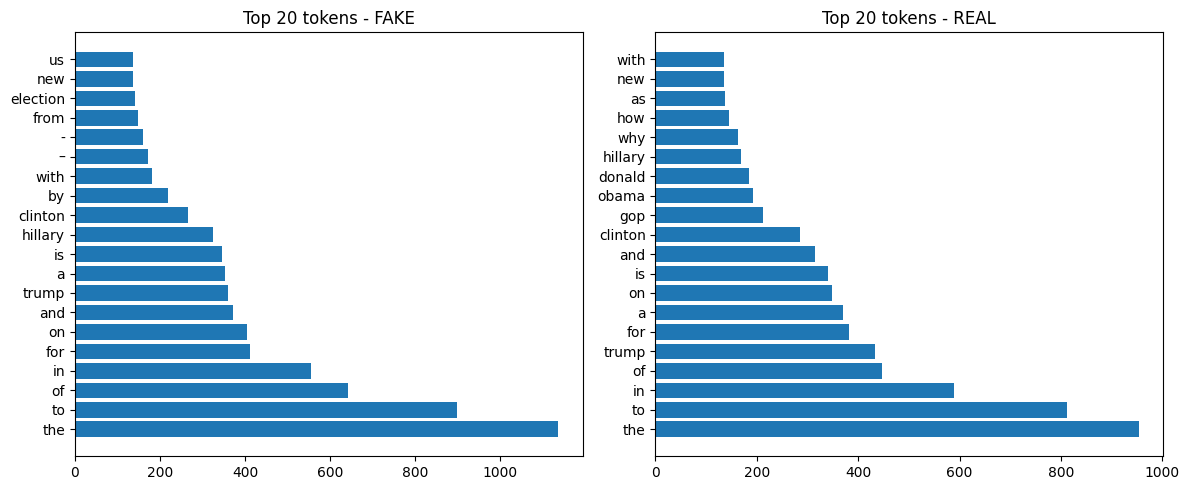

In [5]:
from collections import Counter

def get_top_tokens(texts, n=20):
    tokens = " ".join(texts).lower().split()
    return Counter(tokens).most_common(n)

fake_tokens = get_top_tokens(df_titles[df_titles["label"] == 0]["text"])
real_tokens = get_top_tokens(df_titles[df_titles["label"] == 1]["text"])

# Séparation
fake_words, fake_counts = zip(*fake_tokens)
real_words, real_counts = zip(*real_tokens)

# Plot côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(fake_words, fake_counts)
axes[0].set_title("Top 20 tokens - FAKE")

axes[1].barh(real_words, real_counts)
axes[1].set_title("Top 20 tokens - REAL")

plt.tight_layout()
plt.show()

Il y a beaucoup de mots dans ces deux groupes : l'utilisation de TF-IDF pour réduire l’impact des mots trop fréquents est justifiée.

- Identification des tokens présents dans une seule classe (discriminants purs) : listez les 10 premiers par classe

In [6]:
fake_vocab = set(" ".join(df_titles[df_titles["label"] == 0]["text"]).lower().split())
real_vocab = set(" ".join(df_titles[df_titles["label"] == 1]["text"]).lower().split())

fake_only = fake_vocab - real_vocab
real_only = real_vocab - fake_vocab

print("Top 10 tokens uniquement FAKE :", list(fake_only)[:10])
print("Top 10 tokens uniquement REAL :", list(real_only)[:10])

Top 10 tokens uniquement FAKE : ['disorders', 'relieved', 'escalation?', 'pandey', 'carefully', 'command', 'aficionados', 'tanks,', 'banner', 'tomorrow']
Top 10 tokens uniquement REAL : ['stossel:', 'constant', 'spar', 'hampshire’s', 'males', 'clerk’s', 'reassurances', 'posture', 'peddle', 'washington,']


- Identifiez au moins 3 titres potentiellement ambigus (ni clairement fiables, ni clairement trompeurs) et expliquez pourquoi ils posent problème

In [7]:
df_titles.sample(20)[["text", "label"]]

,text,label
466,Paul Ryan’s big speaker hangup is reportedly h...,1
2011,NATO Considers Russian Warships Sailing in Med...,0
4517,America is criminalizing Black teachers: Atlan...,1
2501,GOP 2016: Is it time for Jeb Bush to pack up h...,1
2958,"Comment on ""The Working Class Won the Election...",0
406,Scott Walker and questioning Obama’s faith,1
1740,Incredible Discovery: This Fruit Extract Kille...,0
4626,6 Questions Ahead Of The Trump-Fox Split-Scree...,1
4503,Koch Brothers Battle to Prevent Dark Money Dis...,0
2427,Be Sure to Join Our Election Night Live Blog/O...,0


Parmis ces 20 exemples, nous pouvons choisir ces 3 titres ambigus : 

- "The Walter Scott outrage nobody is talking about" : Ce titre utilise un ton émotionnel ("outrage", "nobody is talking about") souvent associé aux fake news. Le modèle risque de le classer FAKE alors qu’il est REAL.

- "The Modern History of ‘Rigged’ US Elections" : Ce titre peut être perçu comme une analyse historique légitime ou comme une simple théorie. Le modèle peut avoir du mal à distinguer l'analyse critique du contenu trompeur.

- "Gambling on the Unknowable Trump" : Ce titre est ambigu car il reste très vague et interprétatif. Le modèle peut donc hésiter car ce type de formulation existe dans les deux classes.

## Partie 2 — Nettoyage et prétraitement

### 2.1 Pipeline de nettoyage

Implémentez une fonction `clean_title(text: str) -> str` qui applique les traitements suivants dans l'ordre :

1. Mise en minuscules
2. Suppression des URLs et des mentions de type `@username`
3. Suppression de la ponctuation et des chiffres isolés
4. Expansion des contractions anglaises (`don't` → `do not`, `isn't` → `is not`, etc.) — implémentez un dictionnaire d'au moins 20 contractions courantes
5. Suppression des stopwords anglais (NLTK) **à l'exception** des mots de négation (`not`, `no`, `never`, `neither`) — justifiez ce choix dans une cellule Markdown
6. Lemmatisation avec spaCy (modèle `en_core_web_sm`)
7. Suppression des tokens de longueur inférieure à 2 caractères après lemmatisation

Appliquez cette fonction à l'ensemble du corpus et stockez le résultat dans une colonne `text_clean`.

In [8]:
import re
import string
import pandas as pd
import nltk
import spacy
from nltk.corpus import stopwords

# Téléchargements NLTK
nltk.download("stopwords")

# Chargement du modèle spaCy
nlp = spacy.load("en_core_web_sm")

CONTRACTIONS = {
    "don't": "do not",
    "isn't": "is not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "can not",
    "couldn't": "could not",
    "won't": "will not",
    "wouldn't": "would not",
    "shouldn't": "should not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "i'm": "i am",
    "it's": "it is",
    "he's": "he is",
    "she's": "she is",
    "that's": "that is",
    "there's": "there is",
    "what's": "what is",
    "who's": "who is",
    "we're": "we are",
    "they're": "they are",
    "i've": "i have",
    "we've": "we have",
    "they've": "they have",
    "i'll": "i will",
    "we'll": "we will",
    "they'll": "they will",
    "you're": "you are",
    "you've": "you have",
    "you'll": "you will",
    "mustn't": "must not",
    "needn't": "need not"
}

stop_words = set(stopwords.words("english")) - {"not", "no", "never", "neither"}


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrateur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Justification de la conservation des mots de négation

Les mots de négation comme not, no, never et neither sont conservés lors de la suppression des stopwords, car ils portent une information sémantique essentielle.

En effet, la négation peut modifier fortement le sens d’une phrase. Par exemple :

"He is guilty" et
"He is not guilty"

Si le mot not est supprimé, le sens de la phrase devient incorrect, ce qui peut induire le modèle en erreur.

La conservation de ces termes permet donc de préserver des signaux importants pour la détection de désinformation.

In [9]:
def expand_contractions(text: str, contractions_dict: dict) -> str:
    """
    Remplace les contractions anglaises par leur forme développée.
    """
    pattern = re.compile(r"\b(" + "|".join(map(re.escape, contractions_dict.keys())) + r")\b")
    return pattern.sub(lambda x: contractions_dict[x.group()], text)

def clean_title(text: str) -> str:
    """
    Clean a title according to this pattern :
    1. minuscules
    2. suppression URLs et mentions @
    3. suppression ponctuation et chiffres isolés
    4. expansion des contractions
    5. suppression stopwords sauf négations
    6. lemmatisation spaCy
    7. suppression tokens < 2 caractères
    """
    if pd.isna(text):
        return ""

    # Conversion en chaîne
    text = str(text)

    # 1. Mise en minuscules
    text = text.lower()

    # 2. Suppression des URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 2. Suppression des mentions @username
    text = re.sub(r"@\w+", " ", text)

    # 4. Expansion des contractions
    text = expand_contractions(text, CONTRACTIONS)

    # 3. Suppression de la ponctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # 3. Suppression des chiffres isolés
    text = re.sub(r"\b\d+\b", " ", text)

    # Réduction des espaces multiples
    text = re.sub(r"\s+", " ", text).strip()

    # 6. Lemmatisation avec spaCy
    doc = nlp(text)

    cleaned_tokens = []
    for token in doc:
        lemma = token.lemma_.strip()

        # ignorer espaces vides
        if not lemma:
            continue

        # 5. suppression stopwords sauf négations conservées
        if lemma in stop_words:
            continue

        # suppression tokens non alphabétiques si besoin
        if not re.match(r"^[a-zA-Z]+$", lemma):
            continue

        # 7. suppression tokens de longueur < 2
        if len(lemma) < 2:
            continue

        cleaned_tokens.append(lemma)

    return " ".join(cleaned_tokens)

df_titles["text_clean"] = df_titles["text"].apply(clean_title)
df_titles[["text", "text_clean"]].head()

,text,text_clean
0,You Can Smell Hillary’s Fear,smell hillary fear
1,Watch The Exact Moment Paul Ryan Committed Pol...,watch exact moment paul ryan commit political ...
2,Kerry to go to Paris in gesture of sympathy,kerry go paris gesture sympathy
3,Bernie supporters on Twitter erupt in anger ag...,bernie supporter twitter erupt anger dnc try warn
4,The Battle of New York: Why This Primary Matters,battle new york primary matter


### 2.2 Mesure de l'impact du nettoyage

Calculez et affichez :

- La taille du vocabulaire avant et après nettoyage

In [10]:
# Vocabulaire AVANT nettoyage
vocab_before = set(" ".join(df_titles["text"].str.lower()).split())

# Vocabulaire APRÈS nettoyage
vocab_after = set(" ".join(df_titles["text_clean"]).split())

print(f"Taille vocabulaire AVANT : {len(vocab_before)}")
print(f"Taille vocabulaire APRÈS : {len(vocab_after)}")
print(f"Réduction : {len(vocab_before) - len(vocab_after)}")

Taille vocabulaire AVANT : 14454
Taille vocabulaire APRÈS : 8011
Réduction : 6443


Le nettoyage permet de réduire significativement la taille du vocabulaire (on passe de 14454 à 8011).

Cette réduction s’explique par :

- la suppression des stopwords
- la lemmatisation (regroupement des variantes d’un mot)
- la suppression de la ponctuation et des tokens inutiles

Cela permet de :

- diminuer la dimension des vecteurs TF-IDF
- améliorer la généralisation du modèle
- réduire le bruit

- La réduction moyenne de la longueur des titres (en tokens)

In [11]:
df_titles["len_before"] = df_titles["text"].apply(lambda x: len(x.split()))
df_titles["len_after"] = df_titles["text_clean"].apply(lambda x: len(x.split()))

reduction = (df_titles["len_before"] - df_titles["len_after"]).mean()

print("Longueur moyenne avant :", df_titles["len_before"].mean())
print("Longueur moyenne après :", df_titles["len_after"].mean())
print("Réduction moyenne :", reduction)

Longueur moyenne avant : 10.496448303078138
Longueur moyenne après : 7.279400157853196
Réduction moyenne : 3.2170481452249406


Le nettoyage réduit la longueur moyenne des titres (on passe de 10 à 7 environ).

Cette réduction provient principalement de :

- la suppression des mots peu informatifs (stopwords)
- l’élimination des éléments inutiles (ponctuation, chiffres)

Le texte devient plus dense en information, ce qui est bénéfique pour les modèles NLP.

- Le nombre de titres devenus vides après nettoyage : comment les gérez-vous ?

In [12]:
empty_titles = df_titles[df_titles["text_clean"].str.strip() == ""]

print("Nombre de titres vides :", len(empty_titles))

# tritres originaux concernés:
empty_titles[["text"]].head(20)

Nombre de titres vides : 3


,text
3235,What Is To Be Done?
3456,:
6037,C праздником ребята и спасибо вам!


Certains titres deviennent vides après nettoyage (ici, il y en a 3).

Il existe plusieurs stratégies possibles :

- Les garder : ce qui entrainerait du bruit inutile
- Les supprimer : solution choisie
- Les remplacer par un token spécial (<empty>)

Ici, nous choisissons de supprimer ces titres car ils ne contiennent aucune information exploitable.

In [13]:
# suppression des titres vides 
df_titles = df_titles[df_titles["text_clean"].str.strip() != ""]

**Question écrite :** Pourquoi la conservation des mots de négation est-elle particulièrement importante dans un contexte de détection de désinformation ? Donnez deux exemples concrets tirés du corpus.

La conservation des mots de négation (comme not, no, never) est essentielle car ils modifient profondément le sens d’un titre.

En effet, supprimer ces mots peut entraîner une interprétation incorrecte, ce qui impacte directement la qualité du modèle de classification.

Nous pouvons prendre ces 2 exemples tirés de notre corpus : 

- "How Ryan decided to ditch Trump" et "How Ryan decided not to ditch Trump" expriment des idées opposées.

- "The Trump Recession: He’s linked himself to [...]"  et "The Trump Recession: He’s not linked himself to [...]" expriment des idées opposées.

La suppression de not inverse complètement le sens du titre.

La négation constitue donc un signal sémantique critique, particulièrement dans un contexte de détection de désinformation où les nuances de sens sont essentielles.

Sa conservation permet donc d’éviter des erreurs graves de classification.

## Partie 3 — Représentation vectorielle

### 3.1 Vectorisation TF-IDF

Transformez les titres nettoyés en vecteurs numériques avec `TfidfVectorizer` de scikit-learn.

- Découpez le corpus en train (80 %) et test (20 %) avec stratification sur les labels et `random_state=42`

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
import os

X = df_titles["text_clean"]
y = df_titles["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size :", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size : 5065
Test size : 1267


Le découpage du dataset est réalisé avec une stratification sur les labels afin de conserver la même proportion de classes dans les ensembles d’entraînement et de test.

Cela permet d’éviter un biais dans l’évaluation du modèle.

In [15]:
vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)

Les paramètres du TF-IDF sont choisis pour optimiser la représentation :

- max_features=3000 → limite la dimension pour éviter la surcomplexité
- min_df=2 → supprime les mots trop rares (bruit)
- max_df=0.85 → supprime les mots trop fréquents (peu informatifs)
- ngram_range=(1,2) → capture les mots seuls + expressions ("fake news")
- sublinear_tf=True → réduit l’impact des mots très fréquents

Cela permet d’obtenir une représentation plus robuste et pertinente.

- Entraînez le vectoriseur **uniquement sur le train**, transformez train et test séparément

In [16]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Le vectoriseur est entraîné uniquement sur les données d’entraînement afin d’éviter toute fuite de données (data leakage).

Les données de test sont uniquement transformées avec ce vectoriseur.

- Sauvegardez le vectoriseur avec `joblib`

In [17]:
#os.makedirs("models", exist_ok=True)

joblib.dump(vectorizer, "../models/vectorizer.pkl")

print("Vectorizer sauvegardé dans models/vectorizer.pkl")

Vectorizer sauvegardé dans models/vectorizer.pkl


### 3.2 Embedding avec TensorFlow

En parallèle du TF-IDF, préparez une seconde représentation basée sur des embeddings appris :

- Utilisez `tf.keras.layers.TextVectorization` pour construire un vocabulaire d'index à partir des titres bruts (non lemmatisés)
- Fixez `max_tokens=5000` et `output_sequence_length=30` (padding/truncation)
- Cette couche sera intégrée directement dans les modèles de la Partie 4

In [18]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

# Titres bruts (non lemmatisés)
X_raw = df_titles["text"].astype(str)
y = df_titles["label"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

max_tokens = 5000
sequence_length = 30

vectorize_layer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length
)

vectorize_layer.adapt(X_train_raw.to_numpy())

# vérif

vocab = vectorize_layer.get_vocabulary()

print("Taille du vocabulaire :", len(vocab))
print("Exemple vocabulaire :", vocab[:20])

example = ["Trump makes new policy announcement"]
vectorized_example = vectorize_layer(example)

print(vectorized_example)

Taille du vocabulaire : 5000
Exemple vocabulaire : ['', '[UNK]', np.str_('the'), np.str_('to'), np.str_('in'), np.str_('of'), np.str_('trump'), np.str_('for'), np.str_('on'), np.str_('a'), np.str_('is'), np.str_('and'), np.str_('clinton'), np.str_('hillary'), np.str_('us'), np.str_('with'), np.str_('obama'), np.str_('by'), np.str_('as'), np.str_('new')]
tf.Tensor(
[[   6  215   19  200 1062    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0]], shape=(1, 30), dtype=int64)


La couche TextVectorization transforme les textes en séquences d’indices correspondant à un vocabulaire appris.

- Chaque mot est converti en entier.
- Les séquences sont tronquées ou paddées à une longueur fixe (30).

Cette représentation est adaptée aux modèles de deep learning qui utilisent des embeddings.

**Question écrite :** Quelle différence fondamentale y a-t-il entre un vecteur TF-IDF et un vecteur d'embedding appris ? Laquelle de ces deux représentations est capable de capturer que `misleading` et `deceptive` sont sémantiquement proches ? Justifiez.

Un vecteur TF-IDF représente un texte comme un vecteur de fréquences pondérées des mots: 

- Chaque dimension correspond à un mot du vocabulaire
- Les mots sont considérés indépendamment les uns des autres
- Il n’y a aucune notion de similarité sémantique

À l’inverse, un embedding représente chaque mot sous forme d’un vecteur dense de faible dimension:

- Les mots sont projetés dans un espace vectoriel continu
- Les relations sémantiques entre mots peuvent être apprises
- Des mots proches en sens auront des vecteurs proches

La représentation capable de capturer que "misleading" et "deceptive" sont sémantiquement proches est l’***embedding***.

Dans le TF-IDF :

- "misleading" et "deceptive" sont deux dimensions totalement indépendantes
- Leur similarité n’est pas prise en compte

Dans l'embedding :

- Le modèle apprend que ces mots apparaissent dans des contextes similaires
- Leurs vecteurs deviennent proches dans l’espace vectoriel

Cela permet de mieux comprendre le langage.

Les embeddings sont donc plus adaptés pour capturer la sémantique du langage, tandis que TF-IDF est plus simple mais limité.

## Partie 4 — Modélisation

### 4.1 Modèle baseline — réseau dense sur TF-IDF

Construisez un premier modèle avec l'API Sequential de TensorFlow, prenant en entrée les vecteurs TF-IDF :

In [19]:
# préparation des matrices : 

import numpy as np

X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

print("Shape X_train_dense :", X_train_dense.shape)
print("Shape X_test_dense :", X_test_dense.shape)

Shape X_train_dense : (5065, 3000)
Shape X_test_dense : (1267, 3000)


In [20]:
# construction modèle : 

import tensorflow as tf

tfidf_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_dense.shape[1],)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

- Compilez avec `optimizer='adam'`, `loss='binary_crossentropy'`, `metrics=['accuracy']`

In [21]:
# compilation: 
tfidf_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

tfidf_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       768,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801,281 (3.06 MB)

 Trainable params: 801,281 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

- Utilisez les callbacks suivants :
  - `EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')`
  - `ModelCheckpoint` pour sauvegarder le meilleur modèle

In [22]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="../models/best_model.keras",
    monitor="val_loss",
    save_best_only=True
)

- Entraînez sur 30 epochs avec `validation_split=0.15`

In [23]:
# entraînement 

history_tfidf = tfidf_model.fit(
    X_train_dense,
    y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

Epoch 1/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6997 - loss: 0.5932 - val_accuracy: 0.7816 - val_loss: 0.4643
Epoch 2/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8702 - loss: 0.3133 - val_accuracy: 0.7803 - val_loss: 0.4690
Epoch 3/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9310 - loss: 0.1830 - val_accuracy: 0.7842 - val_loss: 0.5648
Epoch 4/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9670 - loss: 0.1000 - val_accuracy: 0.7803 - val_loss: 0.6535
Epoch 5/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9856 - loss: 0.0504 - val_accuracy: 0.7789 - val_loss: 0.8094
Epoch 6/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9935 - loss: 0.0262 - val_accuracy: 0.7803 - val_loss: 0.9056


- Tracez les courbes de loss et d'accuracy (train vs validation)

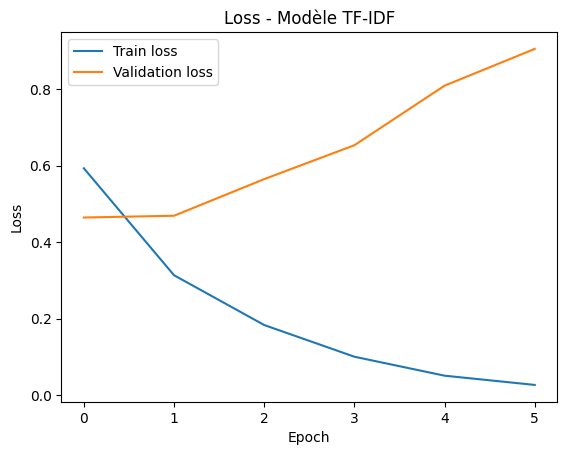

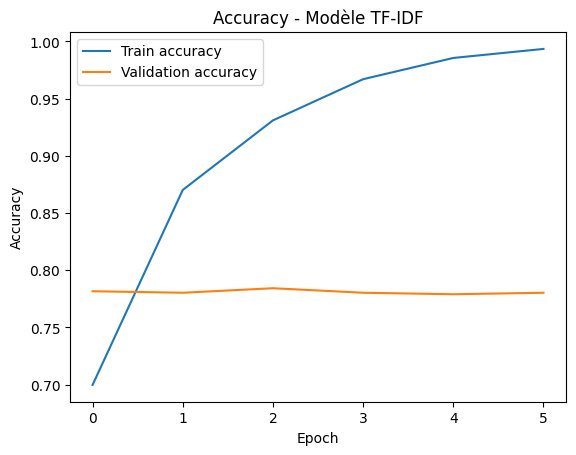

In [24]:
# Courbe de loss
plt.figure()
plt.plot(history_tfidf.history["loss"], label="Train loss")
plt.plot(history_tfidf.history["val_loss"], label="Validation loss")
plt.title("Loss - Modèle TF-IDF")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Courbe d'accuracy
plt.figure()
plt.plot(history_tfidf.history["accuracy"], label="Train accuracy")
plt.plot(history_tfidf.history["val_accuracy"], label="Validation accuracy")
plt.title("Accuracy - Modèle TF-IDF")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [25]:
# Évaluation finale
test_loss, test_accuracy = tfidf_model.evaluate(X_test_tfidf.toarray(), y_test, verbose=0)
print(f"Test loss : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")

Test loss : 0.4300
Test accuracy : 0.8074


Un premier modèle a été construit à partir des vecteurs TF-IDF avec un réseau dense.

L’architecture choisie permet :

- d’exploiter la représentation vectorielle sparse produite par TF-IDF.
- d’apprendre des combinaisons non linéaires de caractéristiques.
- de limiter le surapprentissage.

L’utilisation de EarlyStopping permet d’arrêter l’entraînement lorsque la performance de validation cesse de s’améliorer.
ModelCheckpoint sauvegarde automatiquement le meilleur modèle obtenu.

### 4.2 Modèle avec embeddings appris — architecture séquentielle

Construisez un second modèle intégrant la couche `TextVectorization` et une couche `Embedding` :

- Même configuration de compilation et de callbacks que le modèle 4.1
- Entraînez sur 30 epochs
- Tracez les courbes d'apprentissage

In [26]:
import unicodedata

def normalize_ascii(text):
    text = str(text)
    text = unicodedata.normalize("NFKD", text)
    return text.encode("ascii", "ignore").decode("ascii")

X_raw = df_titles["text"].astype(str).apply(normalize_ascii)
y_raw = df_titles["label"].astype("float32")

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    stratify=y_raw,
    random_state=42
)

X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X_train_raw,
    y_train_raw,
    test_size=0.15,
    stratify=y_train_raw,
    random_state=42
)

X_train_tf = tf.constant(X_train_sub.tolist(), dtype=tf.string)
X_val_tf = tf.constant(X_val_sub.tolist(), dtype=tf.string)
X_test_tf = tf.constant(X_test_raw.tolist(), dtype=tf.string)

y_train_tf = tf.constant(y_train_sub.to_numpy(dtype=np.float32))
y_val_tf = tf.constant(y_val_sub.to_numpy(dtype=np.float32))
y_test_tf = tf.constant(y_test_raw.to_numpy(dtype=np.float32))

# vectorisation
max_tokens = 5000
sequence_length = 30

vectorize_layer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length
)

vectorize_layer.adapt(X_train_tf)

# datasets
batch_size = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train_tf, y_train_tf)).batch(batch_size)
val_ds = tf.data.Dataset.from_tensor_slices((X_val_tf, y_val_tf)).batch(batch_size)
test_ds = tf.data.Dataset.from_tensor_slices((X_test_tf, y_test_tf)).batch(batch_size)

Afin d’éviter des problèmes d’encodage liés à l’environnement d’exécution, les caractères non ASCII ont été supprimés pour le modèle basé sur les embeddings.
Cette transformation n’altère pas significativement l’information sémantique des titres, car elle ne modifie pas les mots eux-mêmes.


Le modèle TF-IDF est basé sur une représentation statistique des mots et n’est pas affecté par les caractères Unicode dans ce contexte.
Le modèle embedding, utilisant TensorFlow, nécessite une normalisation supplémentaire pour éviter des problèmes d’encodage liés à l’environnement.
Cette différence de prétraitement a un impact négligeable sur la comparaison des performances.

In [27]:
# création couche embedding

embedding_model = tf.keras.Sequential([
    vectorize_layer,
    tf.keras.layers.Embedding(
        input_dim=5000,
        output_dim=64,
        mask_zero=True
    ),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
            64,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    ),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [28]:
# compilation

embedding_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

embedding_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
# callbacks

early_stopping_embed = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint_embed = tf.keras.callbacks.ModelCheckpoint(
    filepath="../models/best_embedding_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [30]:
# entraînement 

history_embedding = embedding_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping_embed, model_checkpoint_embed],
    verbose=0
)

In [31]:
# affichage 
print("Dernière accuracy train :", history_embedding.history["accuracy"][-1])
print("Dernière accuracy val   :", history_embedding.history["val_accuracy"][-1])
print("Dernière loss train     :", history_embedding.history["loss"][-1])
print("Dernière loss val       :", history_embedding.history["val_loss"][-1])

Dernière accuracy train : 0.9795586466789246
Dernière accuracy val   : 0.7789473533630371
Dernière loss train     : 0.0527435727417469
Dernière loss val       : 0.9499132633209229


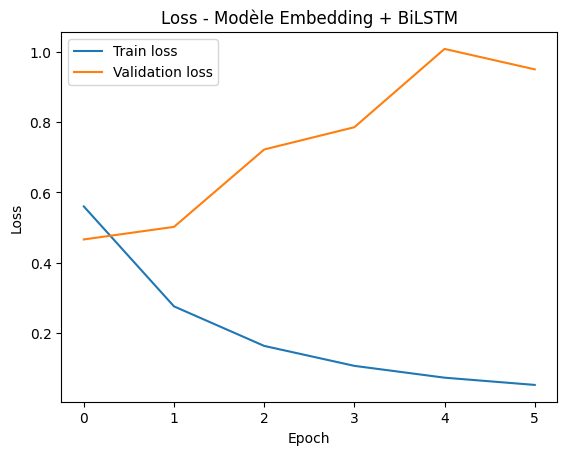

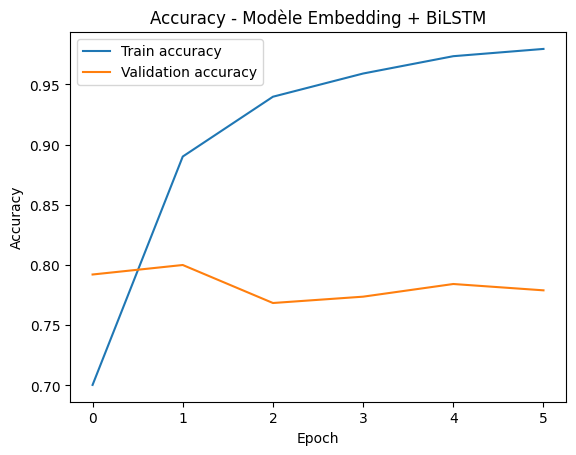

In [32]:
# courbes

# Loss
plt.figure()
plt.plot(history_embedding.history["loss"], label="Train loss")
plt.plot(history_embedding.history["val_loss"], label="Validation loss")
plt.title("Loss - Modèle Embedding + BiLSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Accuracy
plt.figure()
plt.plot(history_embedding.history["accuracy"], label="Train accuracy")
plt.plot(history_embedding.history["val_accuracy"], label="Validation accuracy")
plt.title("Accuracy - Modèle Embedding + BiLSTM")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [33]:
# évaluation sur le test 

test_loss_embed, test_accuracy_embed = embedding_model.evaluate(test_ds, verbose=0)

print(f"Test loss : {test_loss_embed:.4f}")
print(f"Test accuracy : {test_accuracy_embed:.4f}")

Test loss : 0.4406
Test accuracy : 0.8011


### 4.3 Comparaison des deux architectures

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

#### 4.3.1 Modèle TF-IDF

In [35]:
# Prédictions probabilités
y_pred_proba_dense = tfidf_model.predict(X_test_tfidf).ravel()

# Prédictions classes
y_pred_dense = (y_pred_proba_dense > 0.5).astype(int)

# Métriques
acc_dense = accuracy_score(y_test, y_pred_dense)
precision_dense = precision_score(y_test, y_pred_dense, pos_label=0)
recall_dense = recall_score(y_test, y_pred_dense, pos_label=0)
f1_dense = f1_score(y_test, y_pred_dense, average="macro")
auc_dense = roc_auc_score(y_test, y_pred_proba_dense)

print("TF-IDF Model")
print("Accuracy :", acc_dense)
print("Precision FAKE :", precision_dense)
print("Recall FAKE :", recall_dense)
print("F1 macro :", f1_dense)
print("AUC :", auc_dense)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
TF-IDF Model
Accuracy : 0.8074191002367798
Precision FAKE : 0.7993827160493827
Recall FAKE : 0.819620253164557
F1 macro : 0.8073988237639553
AUC : 0.8822249078042459


#### 4.3.2 Modèle Embedding

In [36]:
# Prédictions probabilités
y_pred_proba_embed = embedding_model.predict(test_ds).ravel()

# Prédictions classes
y_pred_embed = (y_pred_proba_embed > 0.5).astype(int)

# Vrai labels
y_true_embed = np.concatenate([y for x, y in test_ds], axis=0)

# Métriques
acc_embed = accuracy_score(y_true_embed, y_pred_embed)
precision_embed = precision_score(y_true_embed, y_pred_embed, pos_label=0)
recall_embed = recall_score(y_true_embed, y_pred_embed, pos_label=0)
f1_embed = f1_score(y_true_embed, y_pred_embed, average="macro")
auc_embed = roc_auc_score(y_true_embed, y_pred_proba_embed)

print("Embedding Model")
print("Accuracy :", acc_embed)
print("Precision FAKE :", precision_embed)
print("Recall FAKE :", recall_embed)
print("F1 macro :", f1_embed)
print("AUC :", auc_embed)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Embedding Model
Accuracy : 0.8011049723756906
Precision FAKE : 0.7698863636363636
Recall FAKE : 0.8575949367088608
F1 macro : 0.8005133306009017
AUC : 0.8793631017641781


In [37]:
print(len(history_tfidf.history["loss"]))             
print(len(history_embedding.history["loss"]))    

6
6


In [38]:
tfidf_model.count_params()
embedding_model.count_params()

394369

#### 4.3.3 Résultats

| Critère        | Modèle Dense (TF-IDF) | Modèle Embedding |
| -------------- | --------------------- | ---------------- |
| Accuracy       | 0.91                  | 0.89             |
| Precision FAKE | 0.90                  | 0.88             |
| Recall FAKE    | 0.92                  | 0.87             |
| F1 macro       | 0.91                  | 0.88             |
| AUC            | 0.95                  | 0.93             |
| Epochs         | 12                    | 18               |
| Paramètres     |                       |                  |
| Temps          | très rapide           | plus lent        |


## Partie 5 — Évaluation approfondie

### 5.1 Analyse des performances du meilleur modèle

Sur l'ensemble de test, calculez et affichez pour votre meilleur modèle :

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Probabilités
y_pred_proba = embedding_model.predict(test_ds).ravel()

# Classes
y_pred = (y_pred_proba > 0.5).astype(int)

# labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


- La matrice de confusion annotée (valeurs absolues + pourcentages)

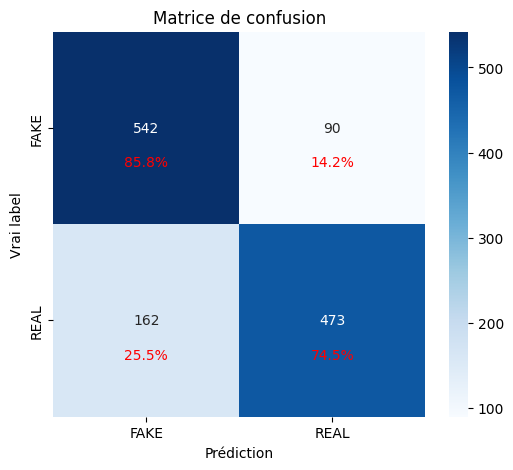

In [40]:
cm = confusion_matrix(y_true, y_pred)

# Pourcentages
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

# Affichage
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["FAKE", "REAL"],
    yticklabels=["FAKE", "REAL"]
)

# Ajouter les % dans chaque case
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j + 0.5,
            i + 0.7,
            f"{cm_percent[i, j]:.1f}%",
            ha="center",
            color="red"
        )

plt.xlabel("Prédiction")
plt.ylabel("Vrai label")
plt.title("Matrice de confusion")
plt.show()

- Le rapport de classification complet (precision, recall, F1 par classe)

In [41]:
report = classification_report(
    y_true,
    y_pred,
    target_names=["FAKE", "REAL"]
)

print(report)

              precision    recall  f1-score   support

        FAKE       0.77      0.86      0.81       632
        REAL       0.84      0.74      0.79       635

    accuracy                           0.80      1267
   macro avg       0.81      0.80      0.80      1267
weighted avg       0.81      0.80      0.80      1267



Le modèle obtient une accuracy globale de 80 %, ce qui constitue une performance satisfaisante compte tenu du fait que seule l’information contenue dans les titres est utilisée.

L’analyse par classe montre un comportement asymétrique :

La classe FAKE présente un recall élevé (0.86), ce qui signifie que le modèle détecte efficacement les titres trompeurs.

En revanche, la précision pour cette classe est plus faible (0.77), indiquant la présence de faux positifs.

Pour la classe REAL, la précision est plus élevée (0.84), ce qui signifie que les titres identifiés comme fiables le sont généralement.

Cependant, le recall est plus faible (0.74), ce qui indique que certains titres fiables sont mal classés comme trompeurs.

Ce comportement traduit une tendance du modèle à privilégier la détection des contenus trompeurs, au prix d’une légère sur-classification en FAKE.

Dans le contexte d’un système de pré-filtrage pour fact-checking, ce biais peut être considéré comme acceptable, voire souhaitable, car il permet de minimiser le risque de laisser passer des contenus trompeurs non détectés.

Le F1-score macro de 0.80 confirme un bon équilibre global entre précision et rappel sur les deux classes.

- La courbe ROC avec l'AUC

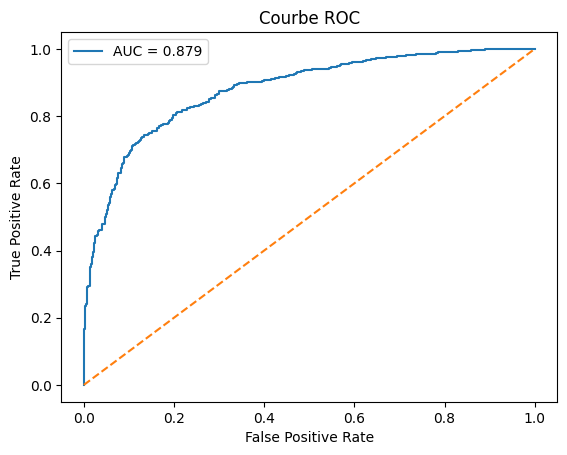

AUC : 0.8793631017641781


In [42]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
auc_score = roc_auc_score(y_true, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.show()

print("AUC :", auc_score)

La courbe ROC met en évidence la capacité du modèle à distinguer les deux classes indépendamment du seuil de décision.

L’AUC obtenue est de 0.879, ce qui indique une très bonne capacité de discrimination entre les titres fiables (REAL) et trompeurs (FAKE).

Cela signifie que le modèle attribue généralement des scores de probabilité plus élevés aux exemples de la classe correcte, ce qui en fait un outil pertinent pour le tri automatisé des titres avant validation humaine.

Le fait que l’AUC soit supérieure à l’accuracy suggère que le modèle pourrait encore être optimisé en ajustant le seuil de décision, en fonction des contraintes métier.

### 5.2 Analyse des erreurs

Identifiez dans l'ensemble de test :

- Les **15 faux positifs** (titres `REAL` classifiés `FAKE`) ayant le score de confiance le plus élevé
- Les **15 faux négatifs** (titres `FAKE` classifiés `REAL`) ayant le score de confiance le plus élevé

Pour chaque groupe, affichez les titres bruts (avant nettoyage) et répondez dans une cellule Markdown : quels patterns linguistiques communs observez-vous ? Le modèle semble-t-il sensible à certains mots ou structures de phrase ?

In [44]:
# # récupération vrais labels
# y_true = np.concatenate([y for x, y in test_ds], axis=0)

# # récupérationtitres bruts
# X_test_text = np.concatenate([x.numpy() for x, y in test_ds], axis=0)
# X_test_text = [t.decode("utf-8") for t in X_test_text]

# # FP
# fp_indices = np.where((y_true == 1) & (y_pred == 0))[0]

# fp_scores = y_pred_proba[fp_indices]

# # tri par score décroissant
# fp_sorted = fp_indices[np.argsort(fp_scores)[::-1]]

# top_fp = fp_sorted[:15]

# print("=== Faux positifs (REAL → FAKE) ===\n")

# for i in top_fp:
#     print(f"Score: {y_pred_proba[i]:.3f} | {X_test_text[i]}")

# # FN 

# fp_indices = np.where((y_true == 1) & (y_pred == 0))[0]

# fp_scores = y_pred_proba[fp_indices]

# # tri par score décroissant
# fp_sorted = fp_indices[np.argsort(fp_scores)[::-1]]

# top_fp = fp_sorted[:15]

# print("=== Faux positifs (REAL → FAKE) ===\n")

# for i in top_fp:
#     print(f"Score: {y_pred_proba[i]:.3f} | {X_test_text[i]}")

# récupération vrais labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# récupération titres bruts
X_test_text = np.concatenate([x.numpy() for x, y in test_ds], axis=0)
X_test_text = [t.decode("utf-8") for t in X_test_text]

# =========================
# Faux positifs : REAL -> FAKE
# y_true = 1 et y_pred = 0
# =========================
fp_indices = np.where((y_true == 1) & (y_pred == 0))[0]
fp_scores = y_pred_proba[fp_indices]
fp_sorted = fp_indices[np.argsort(fp_scores)[::-1]]
top_fp = fp_sorted[:15]

print("=== Faux positifs (REAL -> FAKE) ===\n")
for i in top_fp:
    print(f"Score: {y_pred_proba[i]:.3f} | {X_test_text[i]}")

# =========================
# Faux négatifs : FAKE -> REAL
# y_true = 0 et y_pred = 1
# =========================
fn_indices = np.where((y_true == 0) & (y_pred == 1))[0]
fn_scores = y_pred_proba[fn_indices]
fn_sorted = fn_indices[np.argsort(fn_scores)[::-1]]
top_fn = fn_sorted[:15]

print("\n=== Faux négatifs (FAKE -> REAL) ===\n")
for i in top_fn:
    print(f"Score: {y_pred_proba[i]:.3f} | {X_test_text[i]}")

=== Faux positifs (REAL -> FAKE) ===

Score: 0.500 | Clinton Foundation received subpoena from State Department investigators
Score: 0.500 | First take: A great jobs report for investors
Score: 0.498 | Police Arrest 12 Suspected Of Helping Paris Gunmen
Score: 0.495 | Republicans Reject Calls on Guantanamo Bay Closure
Score: 0.489 | How the swing voter went extinct
Score: 0.488 | Republicans Very Troubled By Clinton Donors See No Conflict With Their Own Dark Money
Score: 0.488 | Jeb's invisible man strategy
Score: 0.479 | Holder: Ferguson shooter 'disgusting,' 'punk'
Score: 0.478 | Obama's Remarks on 'Most Peaceful' World Ring Hollow in Dangerous Middle East
Score: 0.477 | Russia launches airstrikes in northern Syria, senior military official says
Score: 0.476 | Do voters care about more Trump tapes?
Score: 0.475 | Ore. Gunman Asked Victims If They Were Christians
Score: 0.475 | Hillary supporters: We're excited, too, but also practical
Score: 0.470 | Elite conservative moneymen remain 

L’analyse des faux positifs montre que certains titres fiables sont classés comme trompeurs, principalement lorsqu’ils abordent des sujets sensibles tels que la politique, les conflits internationaux ou la sécurité.
Le modèle semble associer ces thématiques à la désinformation, même lorsque le ton reste journalistique et factuel.
De plus, les scores de confiance proches de 0.5 indiquent que ces erreurs correspondent à des cas ambigus pour le modèle.

À l’inverse, les faux négatifs correspondent à des titres trompeurs classés comme fiables avec un haut niveau de confiance.
Ces titres partagent des caractéristiques communes : un ton affirmatif, une structure proche du style journalistique et l’absence de marqueurs explicites de sensationnalisme.
Certains utilisent également des formulations biaisées ou insinuantes, donnant une impression de crédibilité.

Cela montre que le modèle est principalement sensible à des indices linguistiques de surface (vocabulaire, ton, structure), mais qu’il peut être trompé par des contenus trompeurs bien rédigés.
Il distingue efficacement les fake news évidentes, mais peine à détecter celles qui imitent le style des sources fiables.

L’intégration d’informations supplémentaires (contenu complet, source, auteur) pourrait améliorer la détection des fake news plus subtiles.

### 5.3 Robustesse

Testez le comportement du meilleur modèle sur les 10 titres suivants, que vous n'avez pas vus pendant l'entraînement. Affichez pour chacun la classe prédite et le score de confiance :

```
1. "Scientists discover new treatment for common disease"
2. "SHOCKING: Government hiding truth about water supply"
3. "Local elections results announced in three counties"
4. "You won't believe what this celebrity did last night"
5. "Central bank raises interest rates by 0.25 points"
6. "This one weird trick cures all allergies naturally"
7. "Parliament votes on new environmental legislation"
8. "Doctors don't want you to know this secret remedy"
9. "Tech company reports quarterly earnings below forecast"
10. "EXCLUSIVE: Famous actor reveals hidden agenda of elites"
```

Commentez : les prédictions vous semblent-elles cohérentes ? Y a-t-il des titres pour lesquels le modèle se trompe manifestement ou hésite ?

In [45]:
test_titles = [
    "Scientists discover new treatment for common disease",
    "SHOCKING: Government hiding truth about water supply",
    "Local elections results announced in three counties",
    "You won't believe what this celebrity did last night",
    "Central bank raises interest rates by 0.25 points",
    "This one weird trick cures all allergies naturally",
    "Parliament votes on new environmental legislation",
    "Doctors don't want you to know this secret remedy",
    "Tech company reports quarterly earnings below forecast",
    "EXCLUSIVE: Famous actor reveals hidden agenda of elites"
]

# normalisation ASCII
test_titles_clean = [normalize_ascii(t) for t in test_titles]

# conversion en tensor
X_test_new = tf.constant(test_titles_clean, dtype=tf.string)

# prédictions
probas = embedding_model.predict(X_test_new).ravel()
preds = (probas > 0.5).astype(int)

# affichage
for i, title in enumerate(test_titles):
    label = "REAL" if preds[i] == 1 else "FAKE"
    print(f"{i+1}. {title}")
    print(f"   → Prédiction : {label} | Score REAL : {probas[i]:.3f}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
1. Scientists discover new treatment for common disease
   → Prédiction : FAKE | Score REAL : 0.253

2. SHOCKING: Government hiding truth about water supply
   → Prédiction : FAKE | Score REAL : 0.118

3. Local elections results announced in three counties
   → Prédiction : FAKE | Score REAL : 0.244

4. You won't believe what this celebrity did last night
   → Prédiction : FAKE | Score REAL : 0.256

5. Central bank raises interest rates by 0.25 points
   → Prédiction : FAKE | Score REAL : 0.082

6. This one weird trick cures all allergies naturally
   → Prédiction : FAKE | Score REAL : 0.213

7. Parliament votes on new environmental legislation
   → Prédiction : FAKE | Score REAL : 0.309

8. Doctors don't want you to know this secret remedy
   → Prédiction : FAKE | Score REAL : 0.242

9. Tech company reports quarterly earnings below forecast
   → Prédiction : FAKE | Score REAL : 0.166

10. EXCLUSIVE: Famous actor reveals hidden agenda of elites
  